# Q1.2 - Predicting CO2 Emissions from the Energy Mix
**Member 2 · Team Nexora · Branch `feat/q1.2-co2-regression`**

**Question:** How well can a country's CO2 emissions per capita be predicted from its energy mix?

**Approach**
1. Load `country_clean.csv` and remove columns that leak the target
2. Engineer domain features (grid emission factor, VRE share, fuel-switching ratios, country context)
3. Chronological split: train 2000-2020, validate 2021-2026
4. Ridge benchmark vs LightGBM production model (early stopping)
5. Validation suite: ablation, unseen-country test, scenario sanity checks
6. Export the model bundle for Member 4 (Q3 scenarios)

All logic lives in `src/q1_emissions.py`; this notebook calls it and explains the results.

## 1. Setup

In [1]:
import sys, json
sys.path.append("..")                      # notebooks/ -> repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import q1_emissions as q
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 40)

## 2. Data and leakage check
`country_clean.csv` is the canonical table (50 countries x 27 years, zero nulls). Two columns are computed **from CO2 itself**, so using them would leak the answer.

In [2]:
raw = q.load_clean()
print("shape:", raw.shape, "| countries:", raw.iso3.nunique(), "| years:", raw.year.min(), "-", raw.year.max())

r_emis = np.corrcoef(raw["co2_emissions_mt"] / raw["population_millions"], raw[q.TARGET])[0, 1]
r_int = raw[["co2_intensity_kg_per_gdp_usd", q.TARGET]].corr().iloc[0, 1]
print(f"corr(co2_emissions_mt / population, target)  = {r_emis:.5f}   <- reproduces the target")
print(f"corr(co2_intensity_kg_per_gdp_usd, target)   = {r_int:.3f}     <- derived from CO2")
print("\nDropped as leakage:", q.LEAKAGE_COLS)

shape: (1350, 22) | countries: 50 | years: 2000 - 2026
corr(co2_emissions_mt / population, target)  = 0.99996   <- reproduces the target
corr(co2_intensity_kg_per_gdp_usd, target)   = 0.849     <- derived from CO2

Dropped as leakage: ['co2_emissions_mt', 'co2_intensity_kg_per_gdp_usd']


## 3. Feature engineering
Burning coal emits far more CO2 per unit of energy than gas, so features that reflect *how dirty the fuel mix is* should help.

| Feature | Definition | Why |
|---|---|---|
| `grid_emission_factor` | (1.00 coal + 0.75 oil + 0.45 gas) / 100 | weighted carbon intensity of the fuel mix |
| `vre_pct` | solar + wind | intermittent renewables |
| `clean_baseload_pct` | nuclear + hydro | firm low-carbon power (matches AGENTS.md) |
| `fossil_to_renew_ratio` | fossil / (renewables + 0.01) | transition progress |
| `coal_to_gas_ratio` | coal / (gas + 0.01) | fuel-switching signal |
| `low_carbon_pct` | renewables + nuclear | all non-fossil supply |
| `coal_oil_pct` | coal + oil | dirtiest fuels combined |
| `log_population` | log(1 + population) | skew fix |
| `country`, `region` | categorical | country context, needed for Q3 country scenarios |

In [3]:
feat = q.build_features(raw.drop(columns=q.LEAKAGE_COLS))
assert not set(q.LEAKAGE_COLS) & set(q.feature_columns())
print("Model features:", len(q.feature_columns()))
feat[["country", "year"] + q.ENGINEERED_COLS].head()

Model features: 22


,country,year,grid_emission_factor,vre_pct,clean_baseload_pct,fossil_to_renew_ratio,coal_to_gas_ratio,low_carbon_pct,coal_oil_pct,log_population
0,Algeria,2000,0.569,0.420,4.250,20.045,0.028,6.790,48.900,3.669
1,Algeria,2001,0.568,2.410,2.310,16.794,0.021,7.130,49.380,3.679
2,Algeria,2002,0.565,2.390,2.690,12.969,0.032,7.920,48.970,3.686
3,Algeria,2003,0.580,2.800,1.920,22.480,0.009,5.800,51.670,3.694
4,Algeria,2004,0.588,1.630,0.950,34.856,0.016,3.450,50.610,3.701


## 4. Chronological split (no future leakage)

In [4]:
train, val = q.chrono_split(feat)
print(f"train: {len(train)} rows ({train.year.min()}-{train.year.max()})")
print(f"valid: {len(val)} rows ({val.year.min()}-{val.year.max()})")

train: 1050 rows (2000-2020)
valid: 300 rows (2021-2026)


## 5. Train, validate and export
`run_pipeline` fits Ridge (benchmark) and LightGBM (early stopping on 2018-2020, inside the training window, so 2021-2026 stays untouched), runs the validation suite, then refits on all years and saves the bundle to `models/co2_regressor_lgbm.pkl`.

In [5]:
contract = q.run_pipeline(save=True, verbose=False)
ex = contract["_extras"]
results = pd.DataFrame({"Ridge (benchmark)": ex["ridge_metrics"], "LightGBM (production)": ex["lgbm_metrics"]}).T
results

,r2,rmse,mae,mape
Ridge (benchmark),0.939,1.678,1.286,30.676
LightGBM (production),0.967,1.237,0.937,16.998


In [6]:
print("Target R2 > 0.85 met:", contract["metrics"]["r2"] > 0.85)
print({k: v for k, v in contract.items() if k not in ("predictions", "actuals", "features_used", "_extras")})

Target R2 > 0.85 met: True
{'module': 'Q1.2_CO2_Emissions', 'entity': 'GLOBAL_50_COUNTRIES', 'as_of_date': '2026-12-31', 'horizon': 'validation_2021_2026', 'target': 'co2_per_capita_t', 'metrics': {'r2': 0.967, 'rmse': 1.2373}, 'model_name': 'LightGBM Regressor'}


## 6. Actual vs predicted (validation 2021-2026)

In [7]:
ft = q.load_feature_table()
v = ft[ft["split"] == "validation"]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(v[q.TARGET], v["pred_co2_per_capita_t"], s=14, alpha=.6, color="#1D9E75")
lim = [0, v[q.TARGET].max() * 1.05]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set(xlabel="Actual t CO2 / person", ylabel="Predicted", title="LightGBM: actual vs predicted")
by_region = v.assign(abs_err=v["residual"].abs()).groupby("region")["abs_err"].mean().sort_values()
ax[1].barh(by_region.index, by_region.values, color="#888780")
ax[1].set(xlabel="Mean absolute error (t / person)", title="Error by region")
plt.tight_layout(); plt.show()

## 7. What drives emissions?
Left panel: all features. `country` and `population` dominate because countries differ a lot in baseline emissions. Right panel: energy-mix features only, which answers *which fuels matter most*.

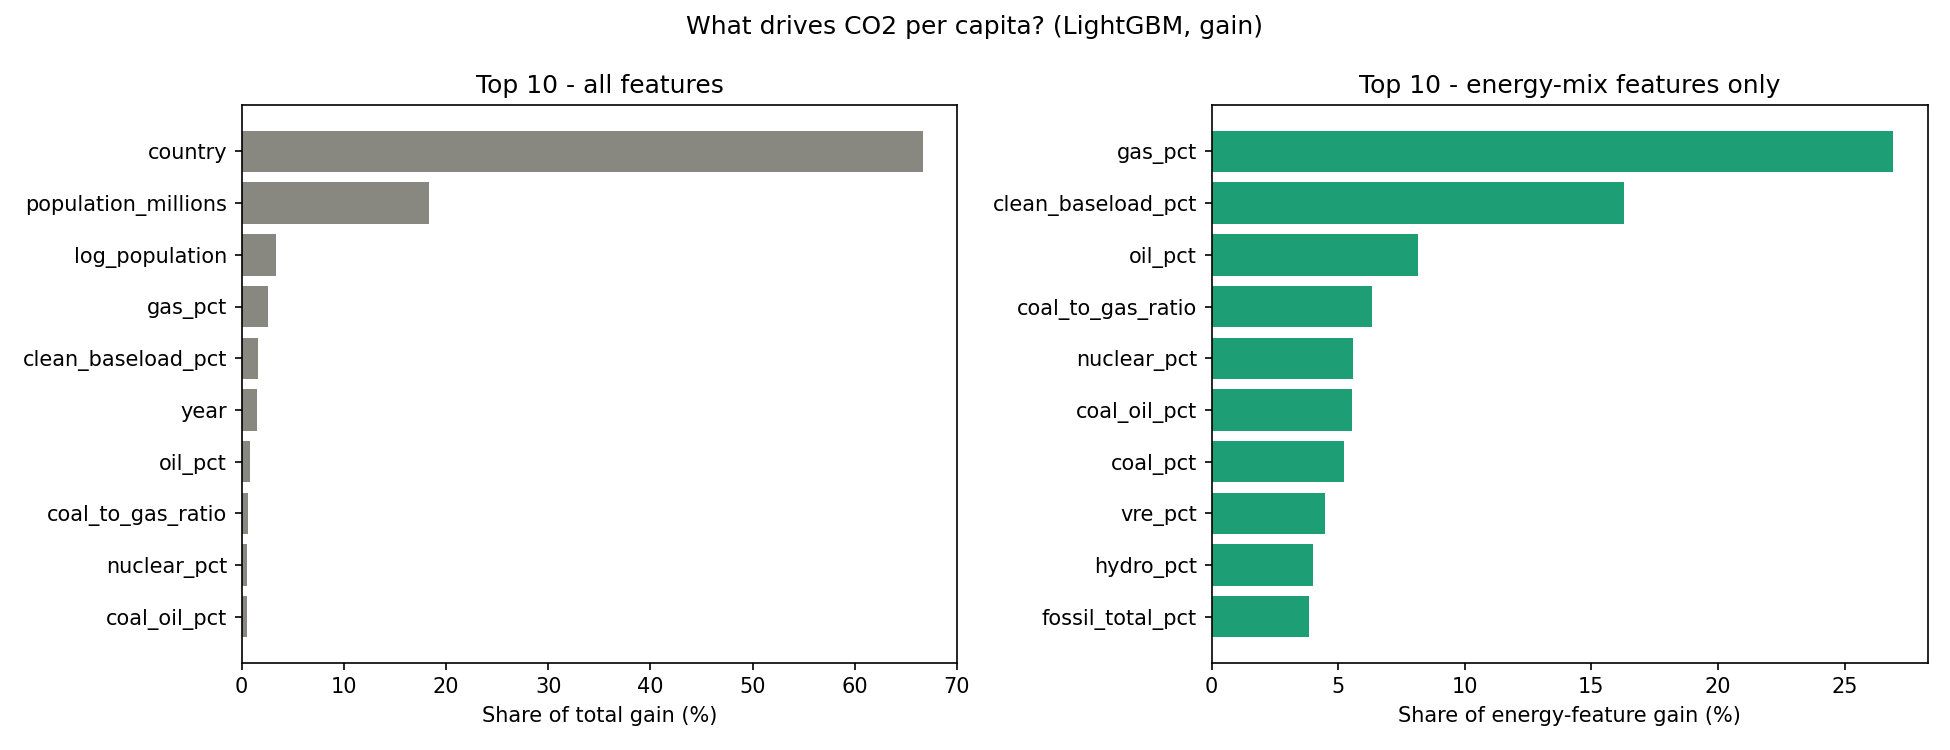

In [8]:
Image("../data/outputs/q1_2_feature_importance.png")

In [9]:
imp = pd.read_csv("../data/outputs/q1_2_feature_importance.csv")
imp[imp.is_energy_feature].head(10)[["feature", "gain_pct_within_energy"]]

,feature,gain_pct_within_energy
3,gas_pct,26.928
4,clean_baseload_pct,16.273
6,oil_pct,8.138
7,coal_to_gas_ratio,6.329
8,nuclear_pct,5.588
9,coal_oil_pct,5.523
10,coal_pct,5.213
11,vre_pct,4.462
12,hydro_pct,4.016
13,fossil_total_pct,3.828


## 8. Ablation: what does each feature group add?
Same model, features removed one group at a time (validation 2021-2026).

In [10]:
pd.read_csv("../data/outputs/q1_2_ablation.csv")

,variant,r2,rmse,mae,mape
0,full,0.964,1.294,0.738,11.871
1,no_year,0.957,1.412,0.792,12.448
2,no_country,0.829,2.820,1.699,34.964
3,no_engineered,0.955,1.439,0.775,11.935
4,raw_shares_only,0.244,5.924,3.588,85.301


**Reading the table**
- Energy-mix shares alone give low R2: fuel mix on its own does not explain differences *between* countries.
- Country context is the biggest single gain.
- Engineered features add a modest improvement on top.

## 9. Limits and scenario sanity checks
**Unseen countries.** Holding out whole countries (GroupKFold by `iso3`) tests whether the model can predict a country it has never seen.

In [11]:
print("GroupKFold (unseen countries):", {k: round(v, 3) for k, v in ex["group_kfold"].items()})

GroupKFold (unseen countries): {'r2': -0.082, 'rmse': 5.352, 'mae': 3.796, 'mape': 78.425}


R2 is about zero for unseen countries, so **the model is valid only for the 50 countries in the data**. That matches the task (predict known countries forward in time) but should be stated as a limitation.

**Scenario direction.** Q3 moves fuel shares (e.g. 10 percentage points from coal). LightGBM is best for levels but responds jaggedly to such edits, so the bundle also includes a country-fixed-effects Ridge for scenario *deltas*.

In [12]:
s = ex["sanity"]
pd.DataFrame({
    "coal -> gas":   [s["lgbm_delta_coal_to_gas"],   s["ridge_delta_coal_to_gas"]],
    "coal -> solar": [s["lgbm_delta_coal_to_solar"], s["ridge_delta_coal_to_solar"]],
    "coal -> wind":  [s["lgbm_delta_coal_to_wind"],  s["ridge_delta_coal_to_wind"]],
}, index=["LightGBM", "FE-Ridge"]).rename_axis("mean change in t CO2 / person (10 pp shift)")

,coal -> gas,coal -> solar,coal -> wind
mean change in t CO2 / person (10 pp shift),,,
LightGBM,0.167,-0.101,-0.134
FE-Ridge,-0.949,-1.346,-2.947


In [13]:
print("Ridge ordering physically correct (coal->solar < coal->gas < 0):", s["ridge_scenarios_physically_ordered"])

Ridge ordering physically correct (coal->solar < coal->gas < 0): True


## 10. Handoff to Member 4
Load the bundle and project a scenario: **projected = LightGBM level + Ridge delta**. Example: Germany with half of its coal share replaced by solar.

In [14]:
b = q.load_bundle()
print("bundle keys:", list(b.keys()))

base = ft[(ft.iso3 == "DEU") & (ft.year == 2026)].copy()
scen = base.copy()
moved = base["coal_pct"] * 0.5
scen["coal_pct"] -= moved; scen["solar_pct"] += moved
scen["fossil_total_pct"] -= moved; scen["renewables_total_pct"] += moved

level = q.predict_emissions(base, b)
delta = q.predict_scenario_delta(base, scen, b)
print(f"Germany 2026 level: {level[0]:.2f} t/person | scenario delta: {delta[0]:+.2f} | projected: {level[0] + delta[0]:.2f}")

bundle keys: ['model', 'scenario_model', 'features', 'categories', 'target', 'model_name', 'train_years', 'best_iteration', 'metrics', 'notes']
Germany 2026 level: 6.64 t/person | scenario delta: -1.24 | projected: 5.39


### Files produced
| File | Used by |
|---|---|
| `models/co2_regressor_lgbm.pkl` | Member 4 (bundle: LightGBM + Ridge + features + categories) |
| `data/processed/country_features.csv` | Member 4 visualisations (engineered features, actuals, predictions, residuals) |
| `data/outputs/q1_2_*.csv / .json / .png` | report and slides |

```python
from src.q1_emissions import load_bundle, predict_emissions, predict_scenario_delta, load_feature_table
```